# Retail Customer Analytics: Sales Prediction, Customer Segmentation and Business Insights

## TASK 1: Business Context, Data Understanding and Statistical Foundations

In [32]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Load Dataset
df = pd.read_excel('Online Retail.xlsx')

In [33]:
 # 1. Basic Data Profiling

# Dataset Shape
print('Shape:', df.shape)

# Display column names
print('Column Names:', df.columns.tolist())

# Display First Five Rows 
print("\nFirst five rows:")
display(df.head())

# Show data type 
print("\n Datatype:")
print(df.dtypes)

# Data dictionary
data_dictionary = pd.DataFrame({
    'column_name': df.columns,
    'meaning': [
        'Unique invoice or transaction number',
        'Unique code identifying the product',
        'Description or name of the product',
        'Number of units purchased in a transaction',
        'Date and time when the transaction occurred',
        'Price of one unit of the product',
        'Unique identification number of the customer',
        'Country associated with the transaction'
    ],
        'attribute_type': [
        'Categorical nominal / Identifier',
        'Categorical nominal / Identifier',
        'Categorical nominal',
        'Numerical discrete',
        'Temporal / Date-time',
        'Numerical continuous',
        'Categorical nominal / Identifier',
        'Categorical nominal'
    ],
    'data_type': [
        'Object (String)',
        'Object (String)',
        'Object (String)',
        'Integer',
        'Datetime',
        'Float',
        'Float',
        'Object (String)'
    ], 
       'why_it_matters': [
        'Transaction identifier',
        'Product identifier',
        'Product categorization and analysis',
        'Direct input for volume and transaction analysis',
        'Enables temporal pattern and trend analysis',
        'Direct input for price and revenue calculations',
        'Customer identifier ',
        'Enables geographic sales comparison'
    ]

})

display(data_dictionary)

Shape: (541909, 8)
Column Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First five rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



 Datatype:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


,column_name,meaning,attribute_type,data_type,why_it_matters
0,InvoiceNo,Unique invoice or transaction number,Categorical nominal / Identifier,Object (String),Transaction identifier
1,StockCode,Unique code identifying the product,Categorical nominal / Identifier,Object (String),Product identifier
2,Description,Description or name of the product,Categorical nominal,Object (String),Product categorization and analysis
3,Quantity,Number of units purchased in a transaction,Numerical discrete,Integer,Direct input for volume and transaction analysis
4,InvoiceDate,Date and time when the transaction occurred,Temporal / Date-time,Datetime,Enables temporal pattern and trend analysis
5,UnitPrice,Price of one unit of the product,Numerical continuous,Float,Direct input for price and revenue calculations
6,CustomerID,Unique identification number of the customer,Categorical nominal / Identifier,Float,Customer identifier
7,Country,Country associated with the transaction,Categorical nominal,Object (String),Enables geographic sales comparison


In [34]:
# Descriptive statistics 

# For Numerical Attributes
numeric_cols = ['Quantity', 'UnitPrice']

# Custom summary table including range and IQR
summary = pd.DataFrame(index=numeric_cols)

summary['count'] = df[numeric_cols].count()
summary['mean'] = df[numeric_cols].mean()
summary['median'] = df[numeric_cols].median()
summary['mode'] = df[numeric_cols].mode().iloc[0]
summary['variance'] = df[numeric_cols].var()
summary['std'] = df[numeric_cols].std()
summary['min'] = df[numeric_cols].min()
summary['max'] = df[numeric_cols].max()

summary['range'] = summary['max'] - summary['min']

summary['Q1'] = df[numeric_cols].quantile(0.25)
summary['Q2'] = df[numeric_cols].quantile(0.50)
summary['Q3'] = df[numeric_cols].quantile(0.75)

summary['IQR'] = summary['Q3'] - summary['Q1']

summary.round(2)

,count,mean,median,mode,variance,std,min,max,range,Q1,Q2,Q3,IQR
Quantity,541909,9.55,3.00,1.00,47559.39,218.08,-80995.00,80995.0,161990.00,1.00,3.00,10.00,9.00
UnitPrice,541909,4.61,2.08,1.25,9362.47,96.76,-11062.06,38970.0,50032.06,1.25,2.08,4.13,2.88


In [35]:
# Mode and frequency tables for categorical attributes
# Top 5 most frequent categories

for col in ['Description', 'Country']:
    print(f"\n{col}")
    print("Mode:", df[col].mode(dropna=True).iloc[0])
    display(df[col].value_counts().head(5).to_frame('count'))


Description
Mode: WHITE HANGING HEART T-LIGHT HOLDER


,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2369
REGENCY CAKESTAND 3 TIER,2200
JUMBO BAG RED RETROSPOT,2159
PARTY BUNTING,1727
LUNCH BAG RED RETROSPOT,1638



Country
Mode: United Kingdom


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533


In [36]:
# Dataset Summary Table
dataset_summary = {
    'Attribute': [
        'Total Records',
        'Time Period',
        'Unique Invoices',
        'Unique Products',
        'Unique Customers',
        'Countries',
        'Columns'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['InvoiceDate'].min().date()} - {df['InvoiceDate'].max().date()}",
        f"{df['InvoiceNo'].nunique():,}",
        f"{df['StockCode'].nunique():,}",
        f"{df['CustomerID'].nunique():,}",
        f"{df['Country'].nunique()}",
        f"{len(df.columns)}"
    ]
}

summary_df = pd.DataFrame(dataset_summary)
print(summary_df.to_string(index=False))


       Attribute                   Value
   Total Records                 541,909
     Time Period 2010-12-01 - 2011-12-09
 Unique Invoices                  25,900
 Unique Products                   4,070
Unique Customers                   4,372
       Countries                      38
         Columns                       8


# Task 2: Data Cleaning, Preprocessing, Feature Engineering and Mathematical Reasoning

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 Duplicate Rows: 5268

Rows with invalid Quantities:
Negative Quantity: 10624
Zero Quantity: 0

Rows with invalid UnitPrice:
Negative UnitPrice: 2
Zero UnitPrice: 2515

Rows with cancelled transactions:
Number of cancelled transactions: 9288
Percentage of cancelled transactions: 1.71 %

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Outlier detection:

Quantity
Lower bound: -12.5
Upper bound: 23.5
Number of outliers: 58619

UnitPrice
Lower bound: -3.07
Upper bound: 8.45
Number of outliers: 39627


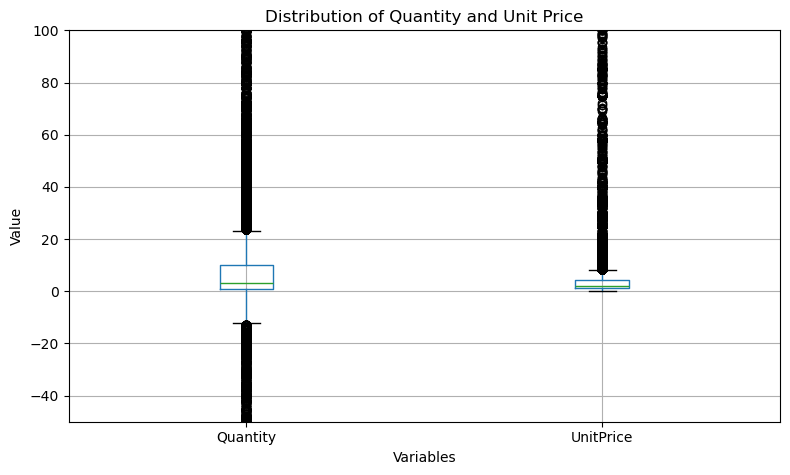

In [37]:
# 1. Check Data Quality / Find Inconsistencies

# Missing values
print('Missing values:\n', df.isnull().sum())

# Duplicate rows
print('\n Duplicate Rows:', df.duplicated().sum())

# Check negative and zero quantities
print('\nRows with invalid Quantities:')
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Zero Quantity:", (df['Quantity'] == 0).sum())


# Check zero and negative UnitPrice
print('\nRows with invalid UnitPrice:')
print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())
print("Zero UnitPrice:", (df['UnitPrice'] == 0).sum())

# Check cancelled transactions
cancelled_transactions = df['InvoiceNo'].astype(str).str.startswith('C')
print('\nRows with cancelled transactions:')
print("Number of cancelled transactions:", cancelled_transactions.sum())
print("Percentage of cancelled transactions:",
      round(cancelled_transactions.mean() * 100, 2), "%")

# Check Data Type
print('\nData types:')
print(df.dtypes)

# Outlier Detection using Interquartile Range (IQR) method
print("\nOutlier detection:")

numeric_cols = ['Quantity', 'UnitPrice']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}")
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Number of outliers:", len(outliers))

# Visualize outliers with boxplot
df.boxplot(column=['Quantity', 'UnitPrice'], figsize=(8, 5))

plt.title('Distribution of Quantity and Unit Price')
plt.suptitle('')
plt.xlabel('Variables')
plt.ylabel('Value')
plt.ylim(-50, 100)
plt.tight_layout()
plt.show()

In [38]:
# 2. Create a cleaned copy
df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Remove cancelled transactions
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')].copy()

# Remove negative quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove zero and negative prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Fill missing product descriptions
df_clean['Description'] = df_clean['Description'].fillna('Unknown')

# Convert CustomerID to nullable integer type
df_clean['CustomerID'] = df_clean['CustomerID'].astype('Int64')

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (541909, 8)
Cleaned dataset shape: (524878, 8)


### Feature Engineering

New features were created to support sales, customer and product analysis.

- `TotalPrice` was calculated as Quantity × UnitPrice.
- `InvoiceMonth`, `InvoiceDay` and `InvoiceHour` were extracted from InvoiceDate.
- Customer-level features included Recency, Frequency, Monetary, AverageBasketValue and UniqueProductsPurchased.
- Product-level features included ProductFrequency, ProductTotalRevenue and ProductAvgPrice.

These features provide additional information for subsequent analysis and modelling.

In [39]:
# Create transaction-level features

df_clean['TotalPrice'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.month
df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.day
df_clean['InvoiceHour'] = df_clean['InvoiceDate'].dt.hour

print("\n Transaction-level features:")
df_clean[
    ['Quantity', 'UnitPrice', 'TotalPrice',
     'InvoiceMonth', 'InvoiceDay', 'InvoiceHour']
].head()


 Transaction-level features:


,Quantity,UnitPrice,TotalPrice,InvoiceMonth,InvoiceDay,InvoiceHour
0,6,2.55,15.30,12,1,8
1,6,3.39,20.34,12,1,8
2,8,2.75,22.00,12,1,8
3,6,3.39,20.34,12,1,8
4,6,3.39,20.34,12,1,8


In [40]:
# Customer-Level Features

# Keep customers with an identified CustomerID
customer_df = df_clean.dropna(subset=['CustomerID']).copy()

# Reference date for Recency
reference_date = (customer_df['InvoiceDate'].max()+ pd.Timedelta(days=1))

# Create RFM features
rfm = customer_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate',
             lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Average spending per order
rfm['AverageBasketValue'] = (rfm['Monetary'] / rfm['Frequency'])

# Number of unique products purchased
customer_products = (
    customer_df.groupby('CustomerID')['StockCode']
    .nunique()
    .reset_index(name='UniqueProductsPurchased')
)

# Add unique product feature to RFM dataset
rfm = rfm.merge(customer_products,on='CustomerID',how='left')

print("\nCustomer-level features:")
print(rfm.head())


Customer-level features:
   CustomerID  Recency  Frequency  Monetary  AverageBasketValue  UniqueProductsPurchased
0       12346      326          1  77183.60        77183.600000                        1
1       12347        2          7   4310.00          615.714286                      103
2       12348       75          4   1797.24          449.310000                       22
3       12349       19          1   1757.55         1757.550000                       73
4       12350      310          1    334.40          334.400000                       17


In [41]:
# Product-Level Features

product_features = df_clean.groupby('StockCode').agg(
    ProductFrequency=('StockCode', 'size'),
    ProductTotalRevenue=('TotalPrice', 'sum'),
    ProductAvgPrice=('UnitPrice', 'mean')
).reset_index()

# Merge product features into transaction dataset
df_clean = df_clean.merge(product_features, on='StockCode',how='left')

print("\nProduct-level features:")
print(product_features.head())

print("\nFinal dataset shape:", df_clean.shape)
print("Final number of columns:", df_clean.shape[1])
print("RFM dataset shape:", rfm.shape)
print("Product features shape:", product_features.shape)


Product-level features:
  StockCode  ProductFrequency  ProductTotalRevenue  ProductAvgPrice
0     10002                71               759.89         1.086620
1     10080                22               119.09         0.410909
2     10120                29                40.32         0.210000
3     10125                93               993.99         0.859785
4     10133               196              1539.60         0.652551

Final dataset shape: (524878, 15)
Final number of columns: 15
RFM dataset shape: (4338, 6)
Product features shape: (3922, 4)


### Encoding, Scaling, Distance Measure and Mathematical Transformation

`Country` was one-hot encoded to convert the categorical variable into numerical values for modelling. `Quantity` and `UnitPrice` were standardised using the Z-score method so that differences in their scales do not disproportionately affect distance-based analysis.

\[
 Z-score:        z = (x - mean) / std\]

Euclidean distance was applied to the standardised features to measure similarity between transactions. Smaller distances indicate more similar observations.

Transaction revenue was calculated as:

\[
TotalPrice=Quantity*times UnitPrice
\]

This transformation converts quantity and unit price into a monetary sales value.

In [42]:
# One-hot encode Country
encoded_country = pd.get_dummies(
    df_clean['Country'],
    prefix='Country',
    drop_first=True,
    dtype=int
)

print(encoded_country.head())

   Country_Austria  Country_Bahrain  Country_Belgium  Country_Brazil  Country_Canada  Country_Channel Islands  \
0                0                0                0               0               0                        0   
1                0                0                0               0               0                        0   
2                0                0                0               0               0                        0   
3                0                0                0               0               0                        0   
4                0                0                0               0               0                        0   

   Country_Cyprus  Country_Czech Republic  Country_Denmark  Country_EIRE  Country_European Community  Country_Finland  \
0               0                       0                0             0                           0                0   
1               0                       0                0             0       

In [43]:
# Standardise numerical features using Z-score

from sklearn.preprocessing import StandardScaler

# Select 2 numerical features to standardize
features = ['Quantity', 'UnitPrice']

scaler = StandardScaler()

# Keep original values
df_standardised = df_clean[features].copy()

# Create Z-score columns
df_standardised[['Quantity_Zscore', 'UnitPrice_Zscore']] = scaler.fit_transform(
    df_standardised[features]
)

# Display original and standardized values
print("Z-Score Standardisation:")
print(df_standardised[
    ['Quantity', 'UnitPrice', 'Quantity_Zscore', 'UnitPrice_Zscore']
].head())

Z-Score Standardisation:
   Quantity  UnitPrice  Quantity_Zscore  UnitPrice_Zscore
0         6       2.55        -0.029541         -0.038029
1         6       3.39        -0.029541         -0.014756
2         8       2.75        -0.016743         -0.032488
3         6       3.39        -0.029541         -0.014756
4         6       3.39        -0.029541         -0.014756


In [44]:
# Euclidean Distance Between Two Customers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

features = ['Recency','Frequency','Monetary','AverageBasketValue']

# Standardise customer features
scaler = StandardScaler()

scaled_features = pd.DataFrame(
    scaler.fit_transform(rfm[features]),
    columns=features,
    index=rfm.index
)

# Select two customers
customer_a = scaled_features.iloc[[0]]
customer_b = scaled_features.iloc[[1]]

# Calculate Euclidean distance
distance = euclidean_distances(customer_a,customer_b)[0, 0]

print("Customer A:", rfm.iloc[0]['CustomerID'])
print("Customer B:", rfm.iloc[1]['CustomerID'])
print("Euclidean Distance:", round(distance, 2))

Customer A: 12346.0
Customer B: 12347.0
Euclidean Distance: 43.52


# TASK 3: REGRESSION MODELLING & EVALUATION

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. # One-hot encode Country (drop first to prevent multicollinearity)
print("\n1. One-hot Encode Country ")

country_dummies = pd.get_dummies(df_clean['Country'], prefix='Country', drop_first=True)
df_clean = pd.concat([df_clean, country_dummies], axis=1)

print(f"Country categories: {df_clean['Country'].nunique()}")
print(f"One-hot dummies created: {country_dummies.shape[1]} (drop_first=True)")


# 2. Select Target and Predictors
print("\n2. Select Target and Predictors")
target = 'TotalPrice'
base_predictors = ['Quantity', 'UnitPrice', 'InvoiceMonth', 'InvoiceDay', 
              'InvoiceHour', 'ProductFrequency', 'ProductAvgPrice']

country_predictors = list(country_dummies.columns)
predictors = base_predictors + country_predictors

X = df_clean[predictors].copy().fillna(0)
y = df_clean[target].copy()


print(f"Target: {target}")
print(f"Base predictors: {len(base_predictors)}")
print(f"Country dummies: {len(country_predictors)}")
print(f"Total predictors: {len(predictors)}")
print(f"Dataset: {X.shape[0]:,} rows × {X.shape[1]} columns")

# 3. Split data before scaling (random_state=42 for reproducibility)

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.20, random_state=42)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.30, random_state=42)

print("\n3. Split Data(Before Scaling)")
print(f"80/20: Train={len(X_train_80):,}, Test={len(X_test_80):,}")
print(f"70/30: Train={len(X_train_70):,}, Test={len(X_test_70):,}")

# 4. Scale after Split (fit on training only) 

scaler_80 = StandardScaler()
X_train_80 = scaler_80.fit_transform(X_train_80)
X_test_80 = scaler_80.transform(X_test_80)

scaler_70 = StandardScaler()
X_train_70 = scaler_70.fit_transform(X_train_70)
X_test_70 = scaler_70.transform(X_test_70)

print(" Scaler fitted on training data only")

# 5. Train and evaluate Linear Regression & Random Forest on given train-test split
print("\n4. Train & Evaluate  Models")
def evaluate_regression_models(X_train, X_test, y_train, y_test, split_name):
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    }
    results = []
    trained_models = {}
    
    for name, model in models.items():
        print(f"Training{name} on {split_name}...")
        model.fit(X_train, y_train)
        trained_models[name] = model
        y_pred = model.predict(X_test)
        
        results.append({
            "Model": name,
            "Split": split_name,
            "MAE (£)": mean_absolute_error(y_test, y_pred),
            "MSE (£²)": mean_squared_error(y_test, y_pred),
            "RMSE (£)": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R-Squared": r2_score(y_test, y_pred)
        })
    
    return pd.DataFrame(results), trained_models, X_test, y_test

# 6. Run Experiments for Both models

print("\n80/20 Split:")
res_80, mods_80, X_t80, y_t80 = evaluate_regression_models(X_train_80, X_test_80, y_train_80, y_test_80, "80/20 Split")

print("\n70/30 Split:")
res_70, mods_70, X_t70, y_t70 = evaluate_regression_models(X_train_70, X_test_70, y_train_70, y_test_70, "70/30 Split")

# 7. Summary Table
print("\n5. Modal Comparison table")
print("-"*70)

metrics_summary = pd.concat([res_80, res_70], ignore_index=True)
print(metrics_summary.to_string(index=False))


1. One-hot Encode Country 
Country categories: 38
One-hot dummies created: 37 (drop_first=True)

2. Select Target and Predictors
Target: TotalPrice
Base predictors: 7
Country dummies: 37
Total predictors: 44
Dataset: 524,878 rows × 44 columns

3. Split Data(Before Scaling)
80/20: Train=419,902, Test=104,976
70/30: Train=367,414, Test=157,464
 Scaler fitted on training data only

4. Train & Evaluate  Models

80/20 Split:
TrainingLinear Regression on 80/20 Split...
TrainingRandom Forest on 80/20 Split...

70/30 Split:
TrainingLinear Regression on 70/30 Split...
TrainingRandom Forest on 70/30 Split...

5. Modal Comparison table
----------------------------------------------------------------------
            Model       Split   MAE (£)     MSE (£²)   RMSE (£)  R-Squared
Linear Regression 80/20 Split 11.272121  2848.986966  53.375902   0.576078
    Random Forest 80/20 Split  0.287255   446.864015  21.139158   0.933508
Linear Regression 70/30 Split 11.838820 56457.157475 237.607149   0.71

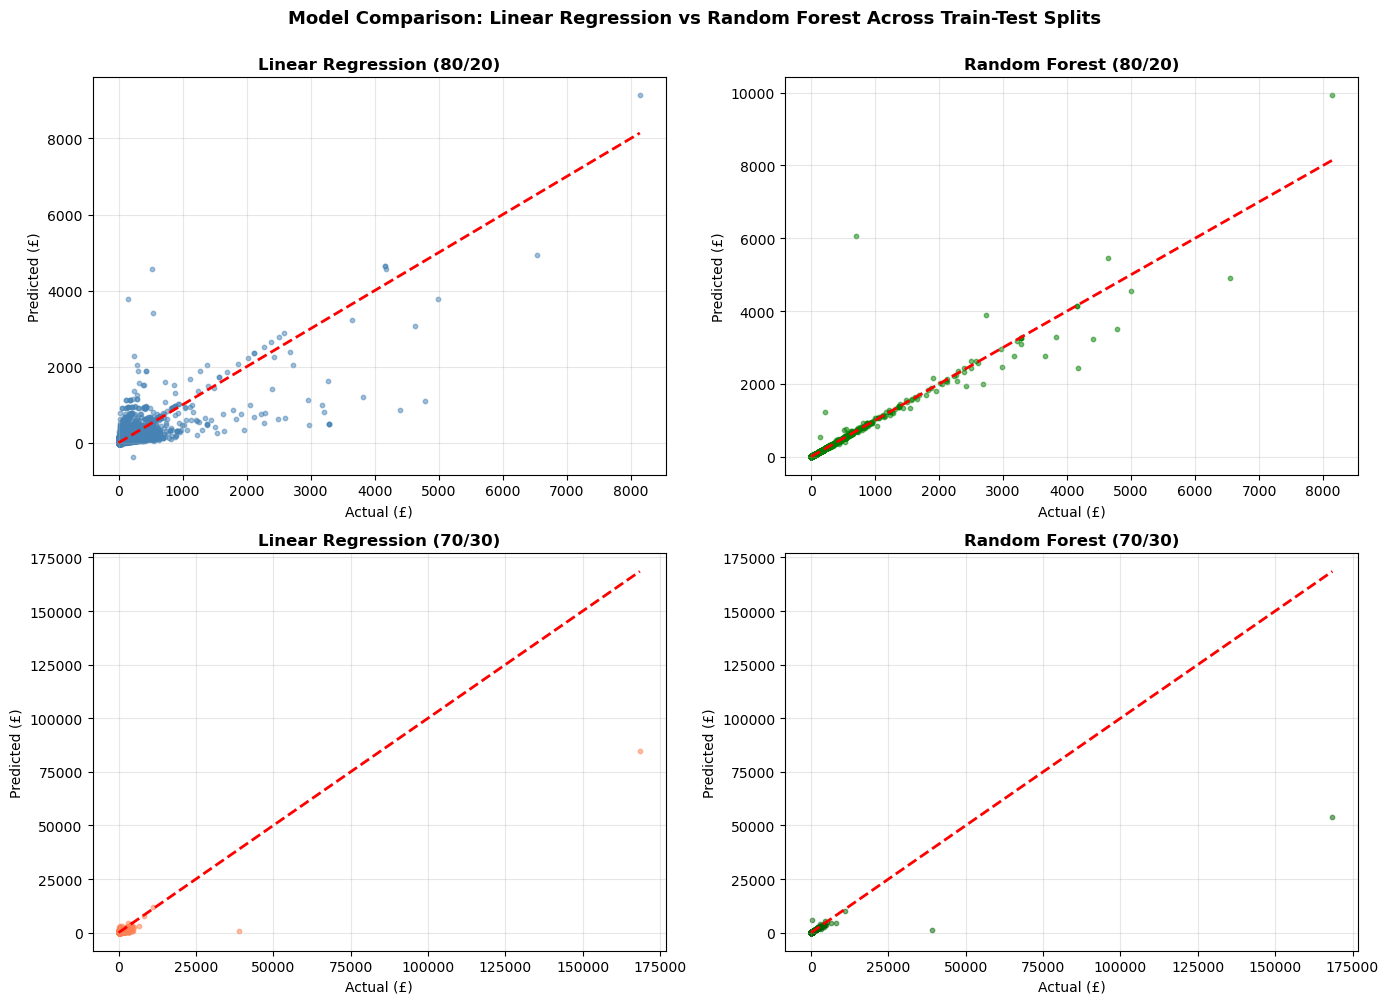

In [46]:
# 8. Actual vs Predicted Plot:  All Models vs All Splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 80/20 - Linear Regression
y_pred_lr_80 = mods_80["Linear Regression"].predict(X_t80)
axes[0, 0].scatter(y_t80, y_pred_lr_80, alpha=0.5, s=10, color='steelblue')
axes[0, 0].plot([y_t80.min(), y_t80.max()], [y_t80.min(), y_t80.max()], 'r--', lw=2)
axes[0, 0].set_title('Linear Regression (80/20)', fontweight='bold')
axes[0, 0].set_xlabel('Actual (£)')
axes[0, 0].set_ylabel('Predicted (£)')
axes[0, 0].grid(True, alpha=0.3)

# 80/20 - Random Forest
y_pred_rf_80 = mods_80["Random Forest"].predict(X_t80)
axes[0, 1].scatter(y_t80, y_pred_rf_80, alpha=0.5, s=10, color='green')
axes[0, 1].plot([y_t80.min(), y_t80.max()], [y_t80.min(), y_t80.max()], 'r--', lw=2)
axes[0, 1].set_title('Random Forest (80/20)', fontweight='bold')
axes[0, 1].set_xlabel('Actual (£)')
axes[0, 1].set_ylabel('Predicted (£)')
axes[0, 1].grid(True, alpha=0.3)

# 70/30 - Linear Regression
y_pred_lr_70 = mods_70["Linear Regression"].predict(X_t70)
axes[1, 0].scatter(y_t70, y_pred_lr_70, alpha=0.5, s=10, color='coral')
axes[1, 0].plot([y_t70.min(), y_t70.max()], [y_t70.min(), y_t70.max()], 'r--', lw=2)
axes[1, 0].set_title('Linear Regression (70/30)', fontweight='bold')
axes[1, 0].set_xlabel('Actual (£)')
axes[1, 0].set_ylabel('Predicted (£)')
axes[1, 0].grid(True, alpha=0.3)

# 70/30 - Random Forest
y_pred_rf_70 = mods_70["Random Forest"].predict(X_t70)
axes[1, 1].scatter(y_t70, y_pred_rf_70, alpha=0.5, s=10, color='darkgreen')
axes[1, 1].plot([y_t70.min(), y_t70.max()], [y_t70.min(), y_t70.max()], 'r--', lw=2)
axes[1, 1].set_title('Random Forest (70/30)', fontweight='bold')
axes[1, 1].set_xlabel('Actual (£)')
axes[1, 1].set_ylabel('Predicted (£)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: Linear Regression vs Random Forest Across Train-Test Splits', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


7. Residual Analysis - All Models & Splits
----------------------------------------------------------------------

80/20 Split:
  Linear Regression - Mean: £-0.03, Std Dev: £53.38
  Random Forest     - Mean: £-0.01, Std Dev: £21.14

70/30 Split:
  Linear Regression - Mean: £0.94, Std Dev: £237.61
  Random Forest     - Mean: £1.04, Std Dev: £304.47


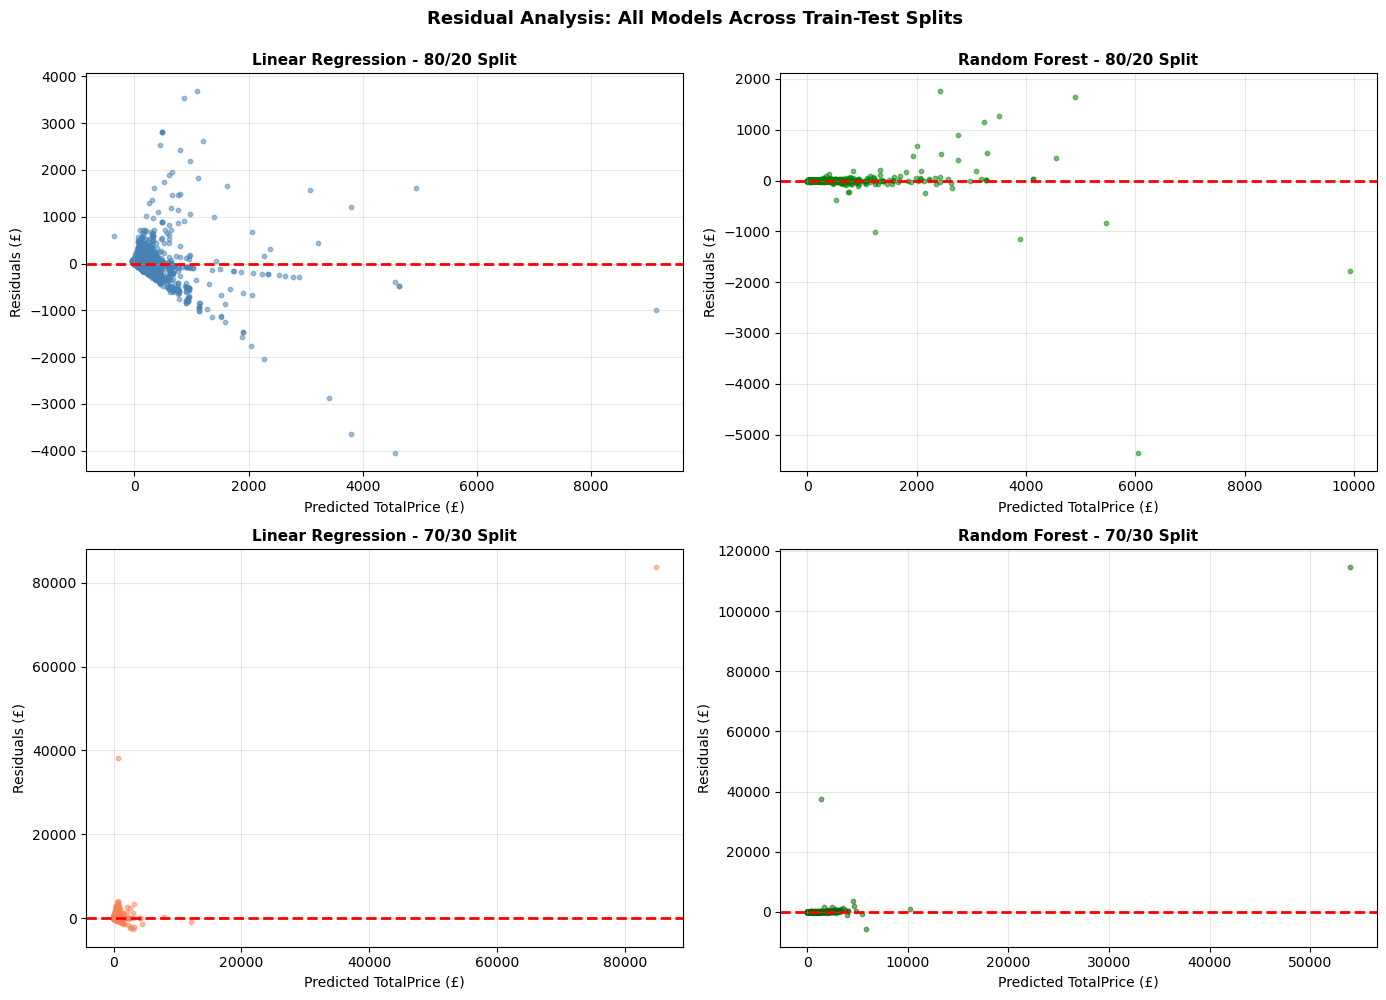


 Residual plots show error distribution (should cluster around y=0)


In [47]:
# 9. Residual Analysis - All Models & Splits
print("\n7. Residual Analysis - All Models & Splits")
print("-"*70)

# Calculate residuals for all 4 combinations
residuals_lr_80 = y_t80 - y_pred_lr_80
residuals_rf_80 = y_t80 - y_pred_rf_80
residuals_lr_70 = y_t70 - y_pred_lr_70
residuals_rf_70 = y_t70 - y_pred_rf_70

# Print summary statistics
print("\n80/20 Split:")
print(f"  Linear Regression - Mean: £{residuals_lr_80.mean():.2f}, Std Dev: £{residuals_lr_80.std():.2f}")
print(f"  Random Forest     - Mean: £{residuals_rf_80.mean():.2f}, Std Dev: £{residuals_rf_80.std():.2f}")

print("\n70/30 Split:")
print(f"  Linear Regression - Mean: £{residuals_lr_70.mean():.2f}, Std Dev: £{residuals_lr_70.std():.2f}")
print(f"  Random Forest     - Mean: £{residuals_rf_70.mean():.2f}, Std Dev: £{residuals_rf_70.std():.2f}")

# Create 2x2 residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 80/20 - Linear Regression
axes[0, 0].scatter(y_pred_lr_80, residuals_lr_80, alpha=0.5, s=10, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted TotalPrice (£)', fontsize=10)
axes[0, 0].set_ylabel('Residuals (£)', fontsize=10)
axes[0, 0].set_title('Linear Regression - 80/20 Split', fontweight='bold', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 80/20 - Random Forest
axes[0, 1].scatter(y_pred_rf_80, residuals_rf_80, alpha=0.5, s=10, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted TotalPrice (£)', fontsize=10)
axes[0, 1].set_ylabel('Residuals (£)', fontsize=10)
axes[0, 1].set_title('Random Forest - 80/20 Split', fontweight='bold', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 70/30 - Linear Regression
axes[1, 0].scatter(y_pred_lr_70, residuals_lr_70, alpha=0.5, s=10, color='coral')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted TotalPrice (£)', fontsize=10)
axes[1, 0].set_ylabel('Residuals (£)', fontsize=10)
axes[1, 0].set_title('Linear Regression - 70/30 Split', fontweight='bold', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 70/30 - Random Forest
axes[1, 1].scatter(y_pred_rf_70, residuals_rf_70, alpha=0.5, s=10, color='darkgreen')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted TotalPrice (£)', fontsize=10)
axes[1, 1].set_ylabel('Residuals (£)', fontsize=10)
axes[1, 1].set_title('Random Forest - 70/30 Split', fontweight='bold', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis: All Models Across Train-Test Splits', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n Residual plots show error distribution (should cluster around y=0)")

# TASK 4 Classification and Clustering for Decision Support

## Part A - Classification Using Decision Tree


1. Create Categorical Target Variable
SalesCategory
Low       179292
High      173646
Medium    171940
Name: count, dtype: int64

2. Train-Test Split (80/20)
Training Set: 419,902 samples
Testing Set:  104,976 samples
Training Distribution: {'Low': 143433, 'High': 138917, 'Medium': 137552}
Testing Distribution:  {'Low': 35859, 'High': 34729, 'Medium': 34388}

First 10 Predictions:
['High' 'Medium' 'Low' 'Medium' 'Low' 'Low' 'Medium' 'High' 'High'
 'Medium']

First 10 Actual Values:
['High', 'Medium', 'Medium', 'Medium', 'Low', 'Medium', 'Medium', 'High', 'High', 'Medium']
Categories (3, object): ['Low' < 'Medium' < 'High']

3. Classification
Accuracy:  57.52%
Precision: 57.51%
Recall:    57.52%
F1-Score:  56.88%

4.Confusion Matrix:
[[19246  7494  7989]
 [ 3545 26570  5744]
 [ 7256 12569 14563]]

Classes: Low(0), Medium(1), High(2)

Classification Report:
              precision    recall  f1-score   support

         Low       0.64      0.55      0.59     34729
      Medium       0.5

<Figure size 800x600 with 0 Axes>

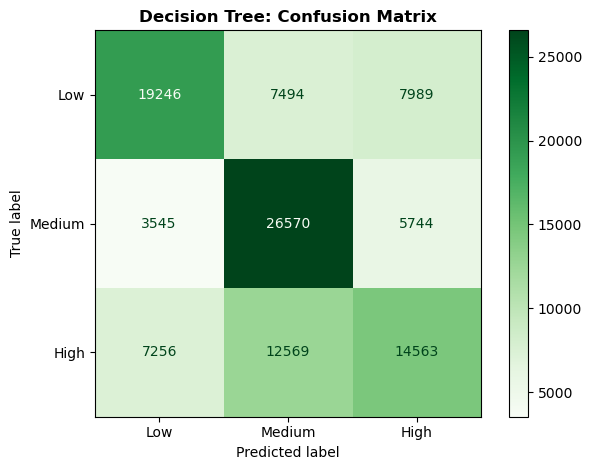

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay

)

# 1. Define Predictors
# Quantity and UnitPrice are excluded to avoid direct target leakage

base_predictors = [ 'InvoiceMonth', 'InvoiceDay', 
                   'InvoiceHour', 'ProductFrequency', 'ProductAvgPrice']

country_predictors = [col for col in df_clean.columns if col.startswith('Country_')]
predictors = base_predictors + country_predictors


# 2. Create Categorical Target
print("\n1. Create Categorical Target Variable")
df_class = df_clean.copy()
df_class['SalesCategory'] = pd.qcut(df_class['TotalPrice'], q=3,
    labels=['Low', 'Medium', 'High']
)
print(df_class['SalesCategory'].value_counts())

# 3. Prepare Data

X = df_class[predictors].copy().fillna(0)
y = df_class['SalesCategory'].copy()



# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)

print("\n2. Train-Test Split (80/20)")
print(f"Training Set: {len(X_train):,} samples")
print(f"Testing Set:  {len(X_test):,} samples")
print(f"Training Distribution: {y_train.value_counts().to_dict()}")
print(f"Testing Distribution:  {y_test.value_counts().to_dict()}")


# 5. Train Decision Tree

dt_clf = DecisionTreeClassifier(criterion='gini',max_depth=10, random_state=42)

dt_clf.fit(X_train, y_train)

# 6. Make Predictions
y_pred = dt_clf.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

#  7. Evaluate Classification Model
print("\n3. Classification")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n4.Confusion Matrix:\n{cm}")
print(f"\nClasses: Low(0), Medium(1), High(2)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High'], zero_division=0))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Greens', values_format='d')
plt.title('Decision Tree: Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()



5. Top 10 Feature Importance
ProductAvgPrice                0.5890
ProductFrequency               0.1394
Country_United Kingdom         0.1229
InvoiceHour                    0.1137
InvoiceMonth                   0.0189
InvoiceDay                     0.0060
Country_Netherlands            0.0060
Country_Spain                  0.0006
Country_Unspecified            0.0006
Country_Japan                  0.0005


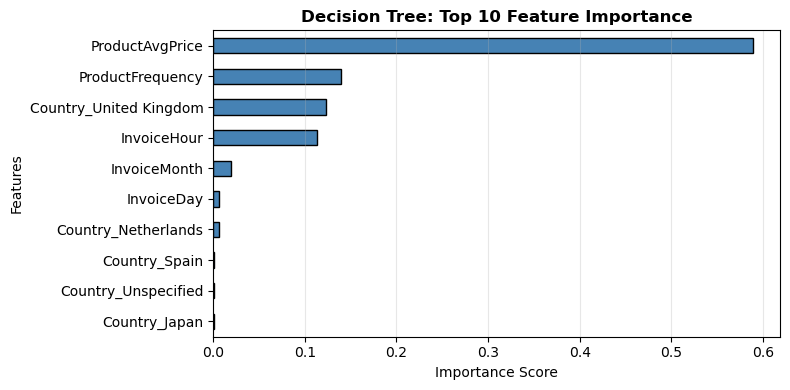

In [49]:
# 9. Feature Importance
print("\n5. Top 10 Feature Importance")

feature_importance = pd.Series(
    dt_clf.feature_importances_,
    index=X.columns  
).sort_values(ascending=False)

for feat, score in feature_importance.head(10).items():
    print(f"{feat:<30} {score:.4f}")

# Visualize Feature Importance
plt.figure(figsize=(8, 4))
feature_importance.head(10).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Decision Tree: Top 10 Feature Importance', fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Part B - K-Means Clustering


1. Select Clustering Features
Features selected: ['ProductFrequency', 'ProductAvgPrice', 'InvoiceMonth', 'InvoiceHour']
Dataset shape: (524878, 4)

2. Scale Clustering Features
Features scaled successfully
Mean: [0. 0. 0. 0.]
Std:  [1. 1. 1. 1.]

3. Elbow Method - Finding Optimal K
----------------------------------------------------------------------
K=2: Inertia = 1691464.34
K=3: Inertia = 1334228.65
K=4: Inertia = 1037291.24
K=5: Inertia = 824909.03
K=6: Inertia = 694290.61
K=7: Inertia = 587280.82
K=8: Inertia = 534440.08
K=9: Inertia = 492131.52
K=10: Inertia = 449963.34


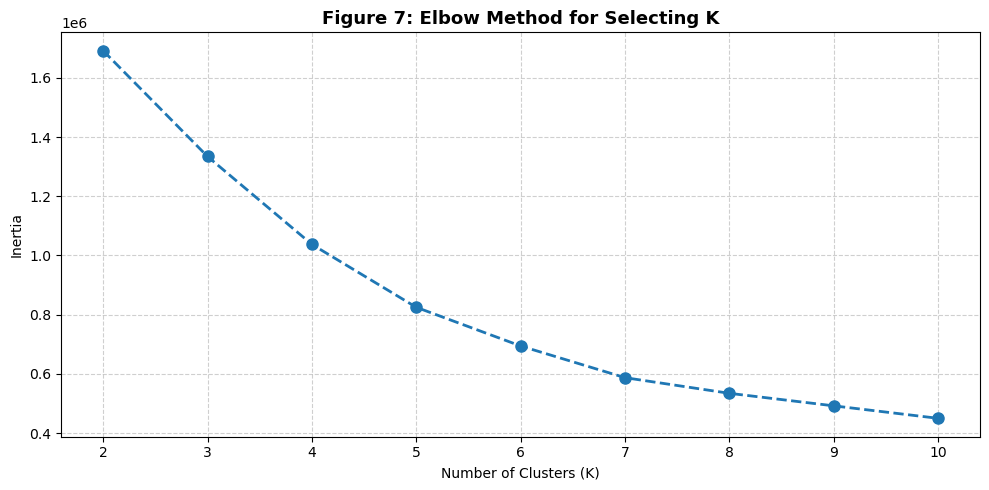

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# 1. Select Features for Clustering 
print("\n1. Select Clustering Features")

# Features: product behavior + temporal patterns (low correlation with target to avoid leakage)
features = ['ProductFrequency','ProductAvgPrice','InvoiceMonth','InvoiceHour']

X = df_clean[features].copy().fillna(0)

print(f"Features selected: {features}")
print(f"Dataset shape: {X.shape}")

# 2. Scale the Features
print("\n2. Scale Clustering Features")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully")
print(f"Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"Std:  {X_scaled.std(axis=0).round(3)}")

# 3. Elbow Method
print("\n3. Elbow Method - Finding Optimal K")
print("-" * 70)

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11),inertia, marker='o',linestyle='--',linewidth=2,markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Figure 7: Elbow Method for Selecting K',fontsize=13,fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



4. Silhouette Score Analysis
----------------------------------------------------------------------
Sample size: 5,000 records

k=2... 0.2384
k=3... 0.2655
k=4... 0.2999
k=5... 0.3079
k=6... 0.2999
k=7... 0.3021
k=8... 0.2687
k=9... 0.2758
k=10... 0.2598

Optimal K from Silhouette: k=5


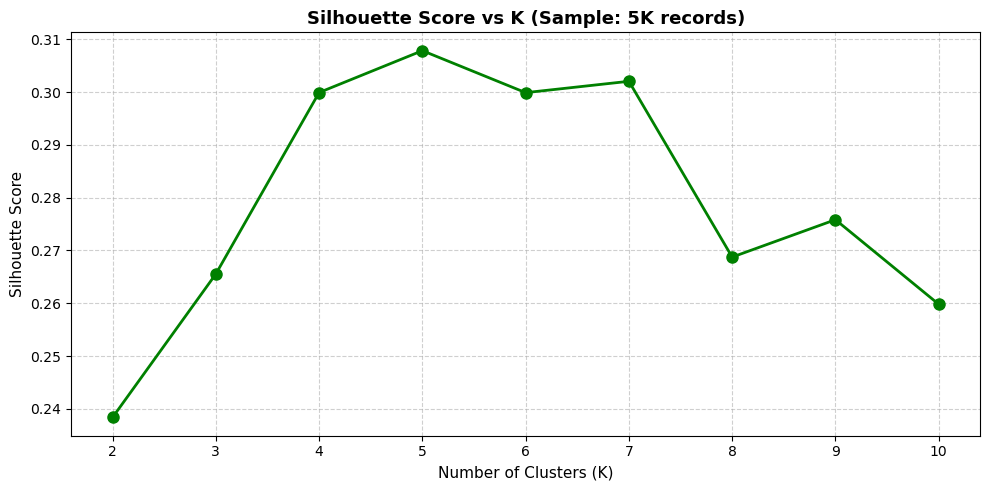

In [51]:
# 4. Silhouette Score Analysis
print("\n4. Silhouette Score Analysis")
print("-" * 70)

# Sample 5,000 records (1% of total) for computational efficiency
# Full dataset would take 30+ min; this 5K sample maintains statistical validity
sample_size = 5000  
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_indices]

print(f"Sample size: {sample_size:,} records\n")

silhouette_scores_list = []

for k in range(2, 11):  
    print(f"k={k}...", end='', flush=True)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=2,max_iter=100 )
    
    clusters_sample = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, clusters_sample)
    silhouette_scores_list.append(score)
    print(f" {score:.4f}")

optimal_k_silhouette = np.argmax(silhouette_scores_list) + 2
print(f"\nOptimal K from Silhouette: k={optimal_k_silhouette}")

# Plot Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores_list, marker='o', linestyle='-', 
         color='green', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Silhouette Score vs K (Sample: 5K records)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



5. Davies-Bouldin Index Analysis
----------------------------------------------------------------------
K=2: Davies-Bouldin Index=1.5439
K=3: Davies-Bouldin Index=1.1028
K=4: Davies-Bouldin Index=0.9639
K=5: Davies-Bouldin Index=0.8577
K=6: Davies-Bouldin Index=0.7581
K=7: Davies-Bouldin Index=0.7948
K=8: Davies-Bouldin Index=0.9146
K=9: Davies-Bouldin Index=0.8959
K=10: Davies-Bouldin Index=0.9466

Optimal K from Davies-Bouldin: K=6


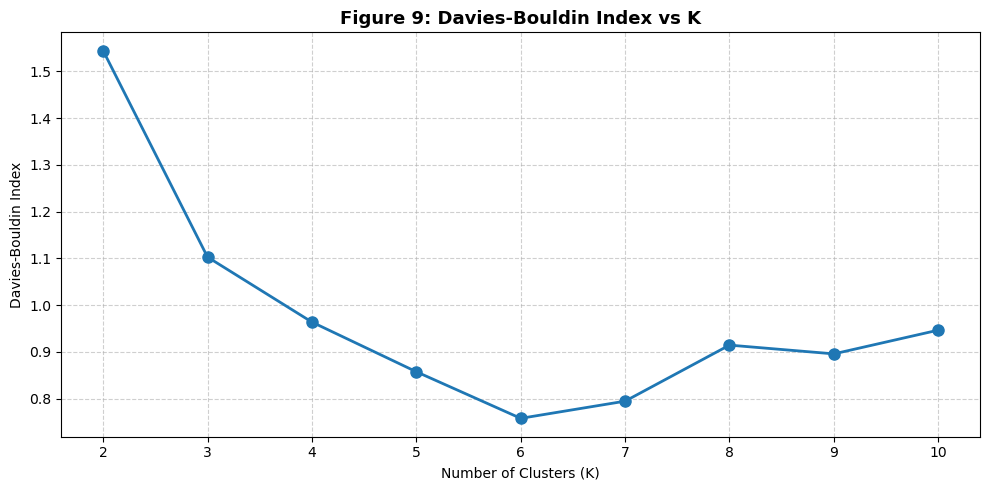

In [52]:
# 5. Davies-Bouldin Index
print("\n5. Davies-Bouldin Index Analysis")
print("-" * 70)

davies_bouldin_scores_list = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    db_score = davies_bouldin_score(X_scaled,clusters)
    davies_bouldin_scores_list.append(db_score)
    print(f"K={k}: "f"Davies-Bouldin Index={db_score:.4f}")


optimal_k_db = (np.argmin(davies_bouldin_scores_list) + 2)
print(f"\nOptimal K from Davies-Bouldin: "f"K={optimal_k_db}")


# Plot Davies-Bouldin Index
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11),davies_bouldin_scores_list,marker='o',linestyle='-',linewidth=2,markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Figure 9: Davies-Bouldin Index vs K',fontsize=13,fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [53]:
# 6. Final K selected based on combined evidence
print("\n6. Select Final Number of Clusters")
print("-" * 70)

print(f"Silhouette Score suggests K = {optimal_k_silhouette}")
print(f"Davies-Bouldin Index suggests K = {optimal_k_db}")
print("Elbow Method suggests K = 5")

optimal_k = 5

print(f"\nSelected final K = {optimal_k}")

print("\nJustification:")
print("- Silhouette Score: Highest at K=5 (0.3077)")
print("- Elbow Method: Clear elbow around K=5")
print("- Davies-Bouldin: K=6 gives the lowest value (0.7581),")
print("  but K=5 also shows a relatively low value (0.8577).")
print("- Overall: K=5 was selected because the Elbow Method and")
print("  Silhouette Score provide stronger support for K=5.")


6. Select Final Number of Clusters
----------------------------------------------------------------------
Silhouette Score suggests K = 5
Davies-Bouldin Index suggests K = 6
Elbow Method suggests K = 5

Selected final K = 5

Justification:
- Silhouette Score: Highest at K=5 (0.3077)
- Elbow Method: Clear elbow around K=5
- Davies-Bouldin: K=6 gives the lowest value (0.7581),
  but K=5 also shows a relatively low value (0.8577).
- Overall: K=5 was selected because the Elbow Method and
  Silhouette Score provide stronger support for K=5.



7. Apply K-Means Clustering

Cluster Distribution:
Cluster
0     71124
1    154811
2    147598
3    151342
4         3
Name: count, dtype: int64

8. Visualize Clusters With PCA


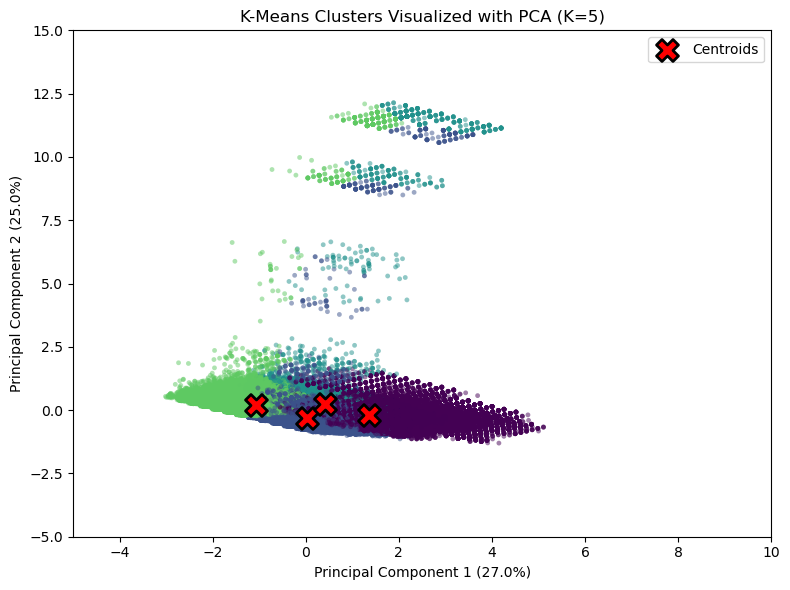


Explained variance: [0.27 0.25]
Total variance explained: 0.520

9. Cluster Characteristics
----------------------------------------------------------------------

Cluster 0:
  Size: 71,124 records
  ProductFrequency: 1190.36
  ProductAvgPrice: £3.57
  InvoiceMonth: 7.3
  InvoiceHour: 12.8

Cluster 1:
  Size: 154,811 records
  ProductFrequency: 309.44
  ProductAvgPrice: £3.64
  InvoiceMonth: 9.9
  InvoiceHour: 11.1

Cluster 2:
  Size: 147,598 records
  ProductFrequency: 299.52
  ProductAvgPrice: £4.42
  InvoiceMonth: 3.3
  InvoiceHour: 12.8

Cluster 3:
  Size: 151,342 records
  ProductFrequency: 292.08
  ProductAvgPrice: £3.73
  InvoiceMonth: 9.4
  InvoiceHour: 15.5

Cluster 4:
  Size: 3 records
  ProductFrequency: 1.67
  ProductAvgPrice: £8274.38
  InvoiceMonth: 7.7
  InvoiceHour: 13.3


In [54]:
# 7. Apply K-Means with selected K 
print("\n7. Apply K-Means Clustering")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clean['Cluster'] = clusters

print("\nCluster Distribution:")
print(df_clean['Cluster'].value_counts().sort_index())

# 8. Visualize Clusters With PCA
print("\n8. Visualize Clusters With PCA")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['Cluster'], cmap='viridis',
           s=12, alpha=0.5, edgecolors='none')

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', marker='X', s=250, edgecolors='black',
           linewidth=2, label='Centroids', zorder=5)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'K-Means Clusters Visualized with PCA (K={optimal_k})')
plt.xlim(-5, 10)
plt.ylim(-5, 15)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nExplained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.3f}")

# 9. Cluster Characteristics
print("\n9. Cluster Characteristics")
print("-" * 70)

for i in range(optimal_k):
    cluster_data = df_clean[df_clean['Cluster'] == i][features]

    print(f"\nCluster {i}:")
    print(f"  Size: {len(cluster_data):,} records")
    print(f"  ProductFrequency: {cluster_data['ProductFrequency'].mean():.2f}")
    print(f"  ProductAvgPrice: £{cluster_data['ProductAvgPrice'].mean():.2f}")
    print(f"  InvoiceMonth: {cluster_data['InvoiceMonth'].mean():.1f}")
    print(f"  InvoiceHour: {cluster_data['InvoiceHour'].mean():.1f}")


# Task 5:  Visualisation, Business Insights and Critical Reflection 

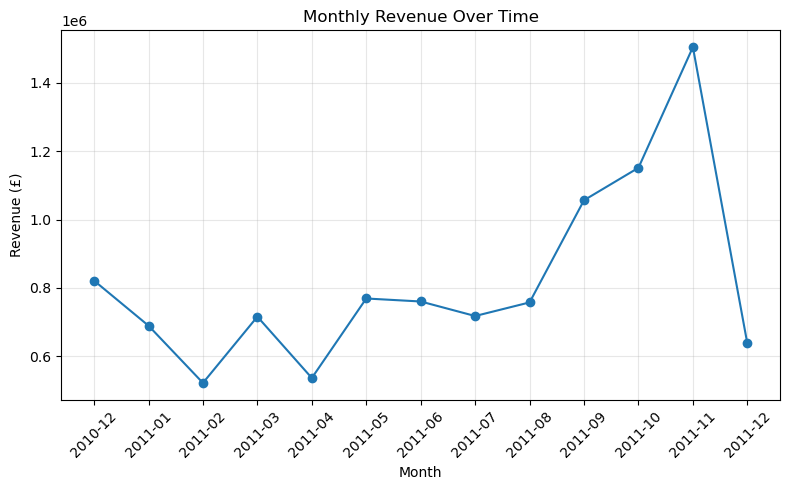

In [55]:
# 1. Revenue Over Time (Trend Analysis)
monthly_revenue = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.title('Monthly Revenue Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

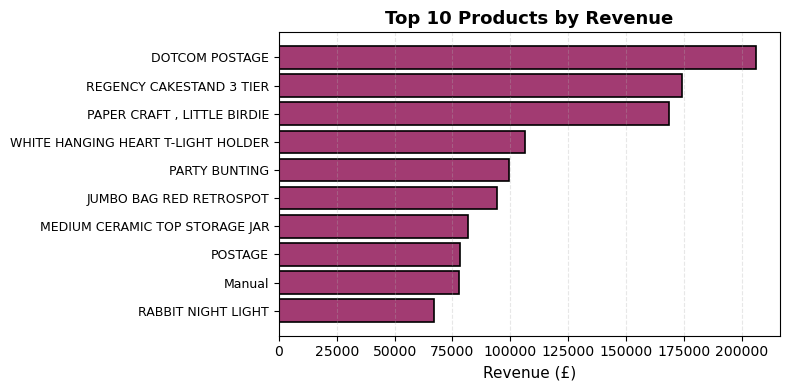

Highest-revenue product: DOTCOM POSTAGE
Revenue: £206248.77


In [56]:
# 2. Top 10 Products by Revenue

top_products = df_clean.groupby('Description')['TotalPrice'].sum().nlargest(10).sort_values()

plt.figure(figsize=(8, 4))
bars = plt.barh(range(len(top_products)), top_products.values, color='#A23B72', edgecolor='black', linewidth=1.2)
plt.yticks(range(len(top_products)), [desc[:35] for desc in top_products.index], fontsize=9)
plt.xlabel('Revenue (£)', fontsize=11)
plt.title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

print(f"Highest-revenue product: {top_products.index[-1]}")
print(f"Revenue: £{top_products.iloc[-1]:.2f}")

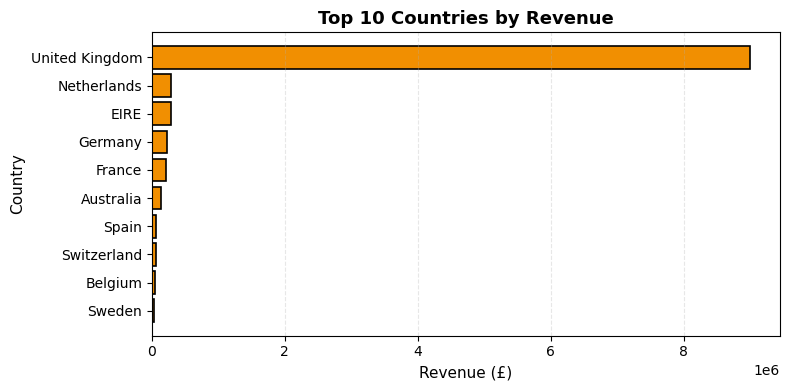

Highest-revenue country: United Kingdom
Revenue: £9,001,744.09


In [57]:
# 3. Country-Level Sales

country_sales = df_clean.groupby('Country')['TotalPrice'].sum().nlargest(10).sort_values()

plt.figure(figsize=(8, 4))
plt.barh(country_sales.index, country_sales.values, color='#F18F01', edgecolor='black', linewidth=1.2)
plt.xlabel('Revenue (£)', fontsize=11)
plt.ylabel('Country', fontsize=11)
plt.title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.savefig('Figure_3_Country_Sales.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Highest-revenue country: {country_sales.index[-1]}")
print(f"Revenue: £{country_sales.iloc[-1]:,.2f}")

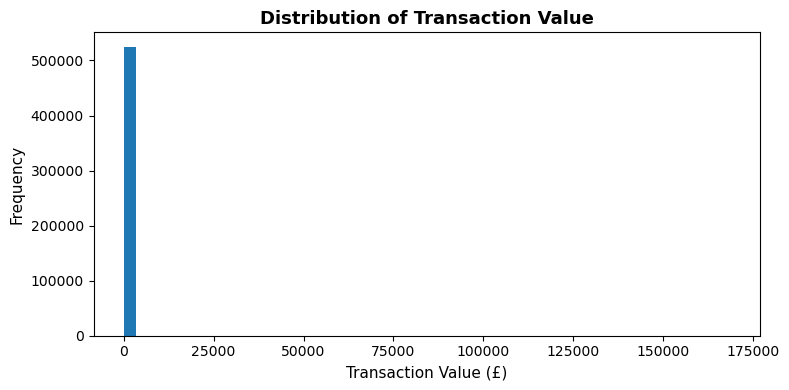

TotalPrice - Mean: £20.28, Median: £9.92


In [58]:
# 4. Distribution of Transaction Value

plt.figure(figsize=(8, 4))
plt.hist(df_clean['TotalPrice'], bins=50)
plt.xlabel('Transaction Value (£)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Transaction Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"TotalPrice - Mean: £{df_clean['TotalPrice'].mean():.2f}, Median: £{df_clean['TotalPrice'].median():.2f}")


<Figure size 800x400 with 0 Axes>

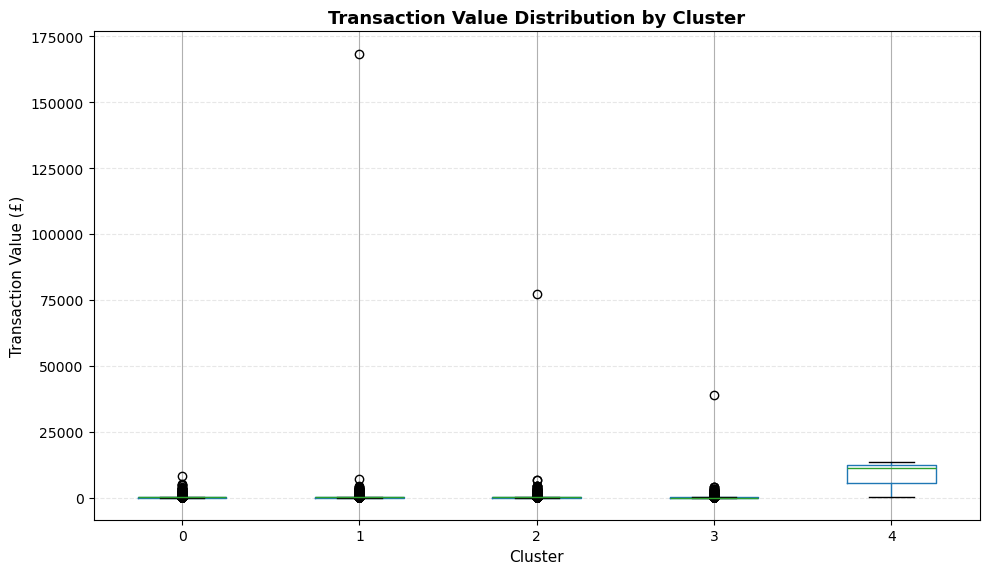

Cluster statistics:
            count     mean      std     min      25%       50%       75%        max
Cluster                                                                            
0         71124.0    29.68    94.43    0.55     5.90     15.00     23.40    8142.75
1        154811.0    21.35   433.58    0.00     4.20     10.20     17.96  168469.60
2        147598.0    18.90   210.86    0.00     4.13      9.96     17.25   77183.60
3        151342.0    15.93   118.65    0.00     2.95      6.72     15.00   38970.00
4             3.0  8274.38  7084.80  219.76  5640.91  11062.06  12301.70   13541.33


In [59]:
# 5: Boxplot- TTransaction Value Distribution by Cluster

plt.figure(figsize=(8, 4))
df_clean.boxplot(column='TotalPrice', by='Cluster', figsize=(10, 6))
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Transaction Value (£)', fontsize=11)
plt.title('Transaction Value Distribution by Cluster', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

print("Cluster statistics:")
print(df_clean.groupby('Cluster')['TotalPrice'].describe().round(2))

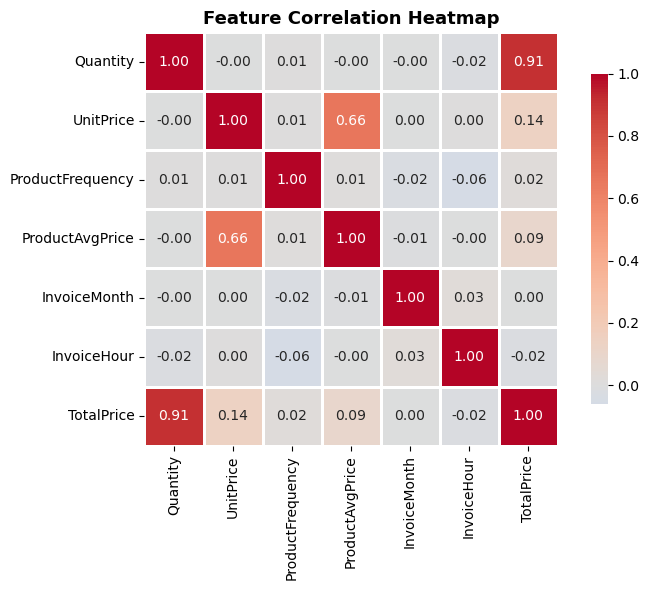

Top correlations with TotalPrice:
TotalPrice          1.000000
Quantity            0.907402
UnitPrice           0.137381
ProductAvgPrice     0.089489
ProductFrequency    0.021972
InvoiceMonth        0.000465
InvoiceHour        -0.015683
Name: TotalPrice, dtype: float64


In [60]:
# 6. Feature Correlation Heatmap

import seaborn as sns
numeric_cols = ['Quantity', 'UnitPrice', 'ProductFrequency', 'ProductAvgPrice', 'InvoiceMonth', 'InvoiceHour', 'TotalPrice']
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top correlations with TotalPrice:")
print(correlation_matrix['TotalPrice'].sort_values(ascending=False))